# Exploratory Data Analysis (EDA)
## Customer Personality Analysis Dataset

**Module 04 — Machine Learning Internship (AI Lab 99)**

This notebook explores customer demographics, spending behaviour, purchasing
channels, website engagement, campaign performance, complaints, correlations,
and segments, and closes with business insights and recommendations.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette("viridis")
%matplotlib inline

DATA_FILE = Path("00_Data/customer_personality_cleaned.csv")
df = pd.read_csv(DATA_FILE)
df.shape

(2237, 33)

## Task 1 — Dataset Overview

In [2]:
print("Shape:", df.shape)
df.head()

Shape: (2237, 33)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Enrollment_Year,Enrollment_Month,Enrollment_Day,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,2012,9,4,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,2014,3,8,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,2013,8,21,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,3,11,0,2014,2,10,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,3,11,0,2014,1,19,45


In [3]:
df.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
Enrollment_Year          int64
Enrollment_Month         int64
Enrollment_Day           int64
Age     

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2237.0,5590.726419,3245.118591,0.0,2829.0,5455.0,8427.0,11191.0
Year_Birth,2237.0,1968.901654,11.701917,1940.0,1959.0,1970.0,1977.0,1996.0
Income,2237.0,51854.814037,20936.241476,1730.0,35523.0,51381.5,68281.0,117418.0
Kidhome,2237.0,0.444345,0.538467,0.0,0.0,0.0,1.0,2.0
Teenhome,2237.0,0.506482,0.544593,0.0,0.0,0.0,1.0,2.0
Recency,2237.0,49.104604,28.956073,0.0,24.0,49.0,74.0,99.0
MntWines,2237.0,303.995530,336.574382,0.0,24.0,174.0,504.0,1493.0
MntFruits,2237.0,26.270451,39.715972,0.0,1.0,8.0,33.0,199.0
MntMeatProducts,2237.0,166.916853,225.661158,0.0,16.0,67.0,232.0,1725.0
MntFishProducts,2237.0,37.523022,54.639909,0.0,3.0,12.0,50.0,259.0


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["ID"].duplicated().sum())
print("Total missing values:", df.isna().sum().sum())

Duplicate rows: 0
Duplicate IDs: 0
Total missing values: 0


## Task 2 — Customer Demographic Analysis

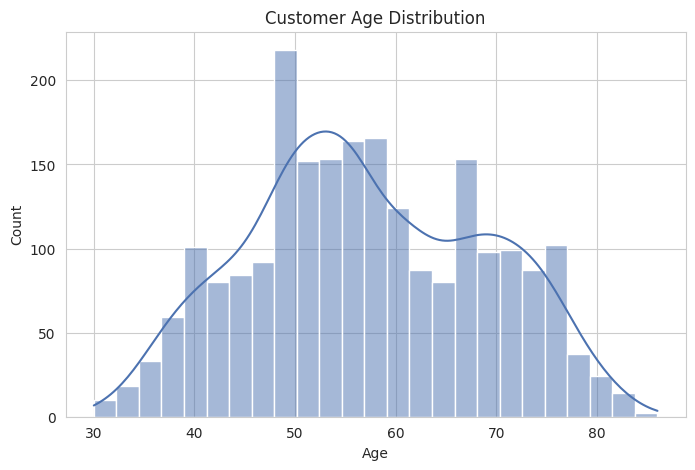

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=25, kde=True, color="#4C72B0")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.show()

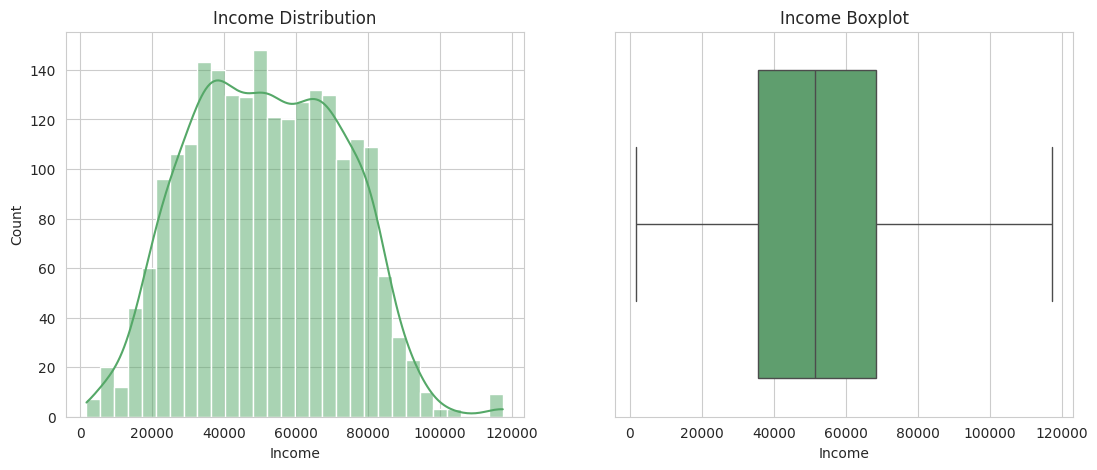

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(df["Income"], bins=30, kde=True, ax=axes[0], color="#55A868")
axes[0].set_title("Income Distribution")
sns.boxplot(x=df["Income"], ax=axes[1], color="#55A868")
axes[1].set_title("Income Boxplot")
plt.show()

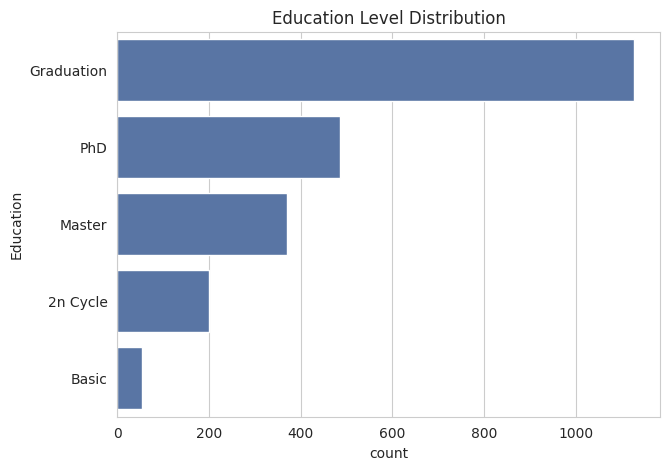

In [8]:
plt.figure(figsize=(7,5))
order = df["Education"].value_counts().index
sns.countplot(y=df["Education"], order=order, color="#4C72B0")
plt.title("Education Level Distribution")
plt.show()

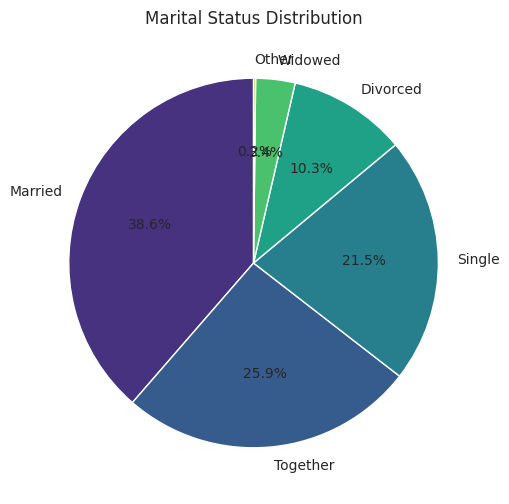

In [9]:
plt.figure(figsize=(6,6))
counts = df["Marital_Status"].value_counts()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Marital Status Distribution")
plt.show()

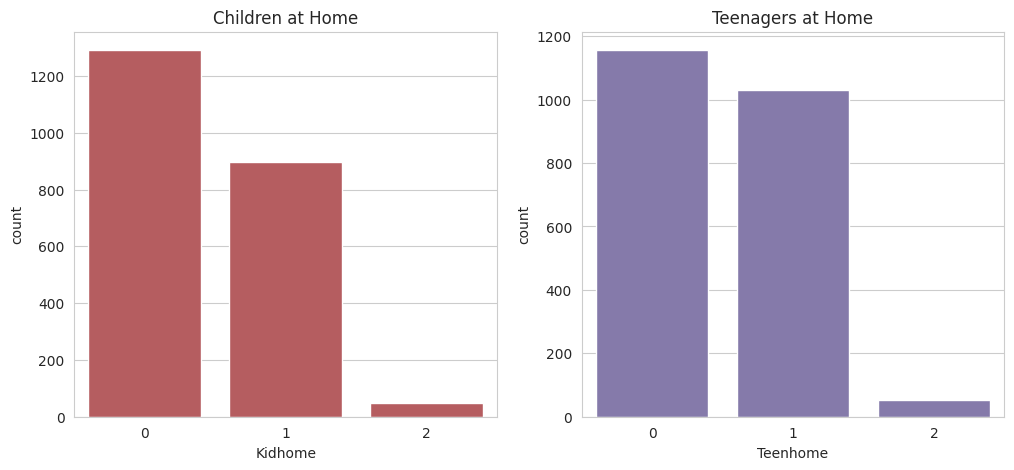

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x=df["Kidhome"], ax=axes[0], color="#C44E52")
axes[0].set_title("Children at Home")
sns.countplot(x=df["Teenhome"], ax=axes[1], color="#8172B2")
axes[1].set_title("Teenagers at Home")
plt.show()

## Task 3 — Customer Spending Analysis

In [11]:
SPEND_COLS = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
df["Total_Spend"] = df[SPEND_COLS].sum(axis=1)

print("Total spending (all customers):", df["Total_Spend"].sum())
print("Average spending per customer:", round(df["Total_Spend"].mean(), 2))

category_totals = df[SPEND_COLS].sum().sort_values(ascending=False)
category_totals

Total spending (all customers): 1355048
Average spending per customer: 605.74


MntWines            680038
MntMeatProducts     373393
MntGoldProds         98358
MntFishProducts      83939
MntSweetProducts     60553
MntFruits            58767
dtype: int64

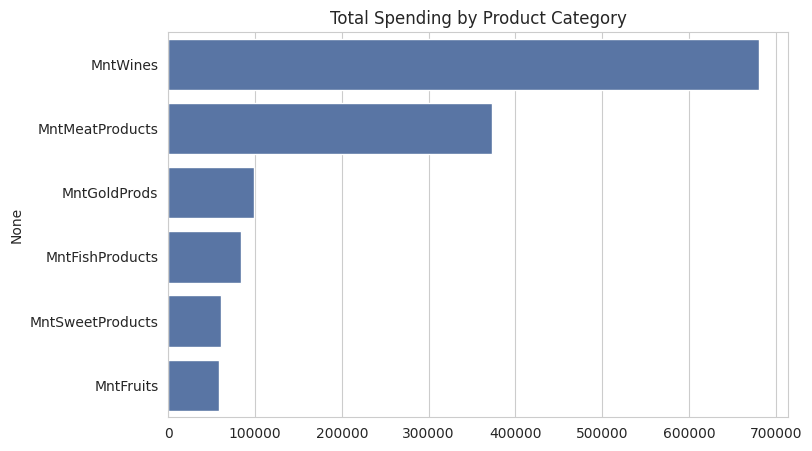

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_totals.values, y=category_totals.index, color="#4C72B0")
plt.title("Total Spending by Product Category")
plt.show()

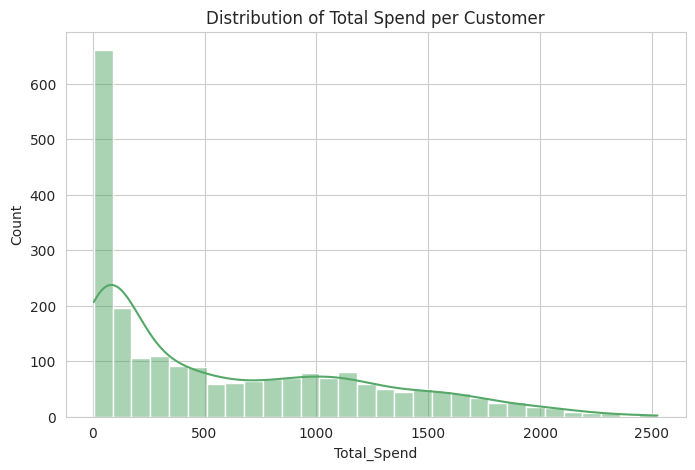

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Total_Spend"], bins=30, kde=True, color="#55A868")
plt.title("Distribution of Total Spend per Customer")
plt.show()

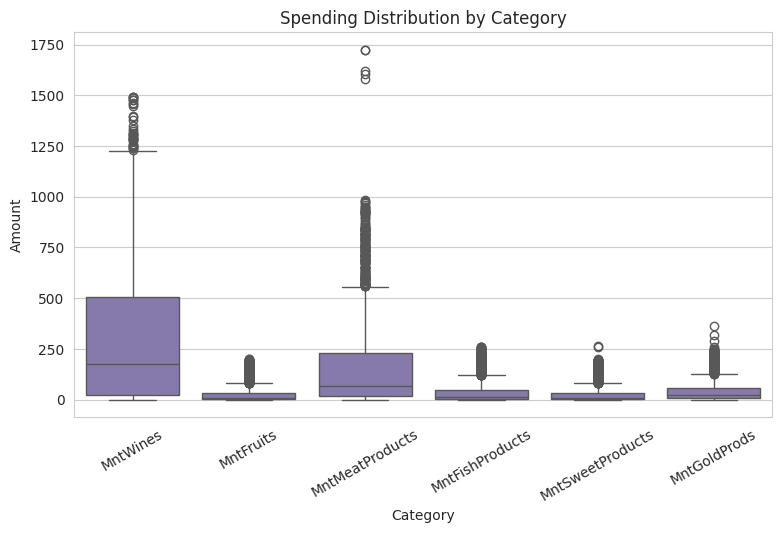

In [14]:
melted = df[SPEND_COLS].melt(var_name="Category", value_name="Amount")
plt.figure(figsize=(9,5))
sns.boxplot(x="Category", y="Amount", data=melted, color="#8172B2")
plt.xticks(rotation=30)
plt.title("Spending Distribution by Category")
plt.show()

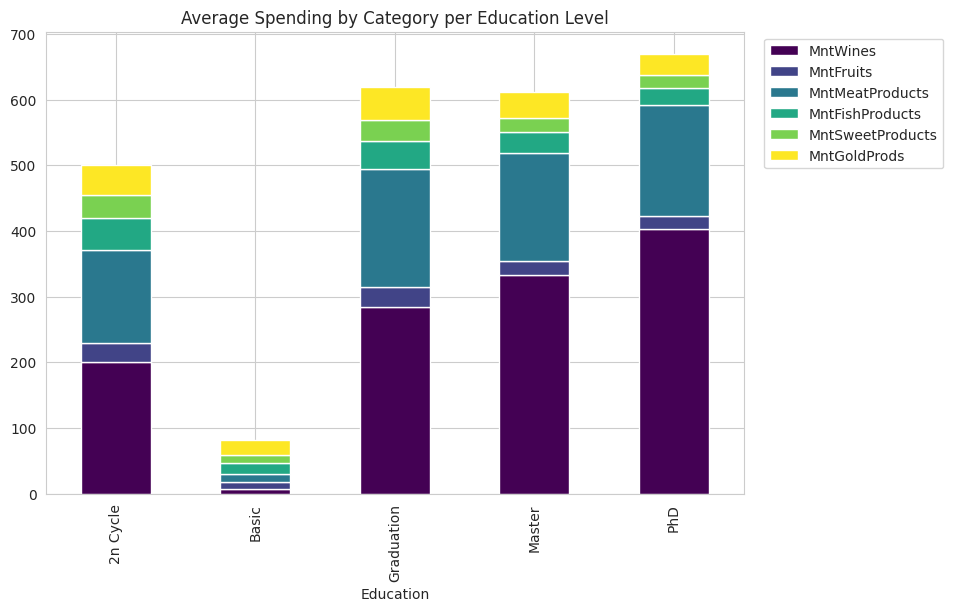

In [15]:
edu_spend = df.groupby("Education")[SPEND_COLS].mean()
edu_spend.plot(kind="bar", stacked=True, figsize=(9,6), colormap="viridis")
plt.title("Average Spending by Category per Education Level")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()

## Task 4 — Purchasing Behavior Analysis

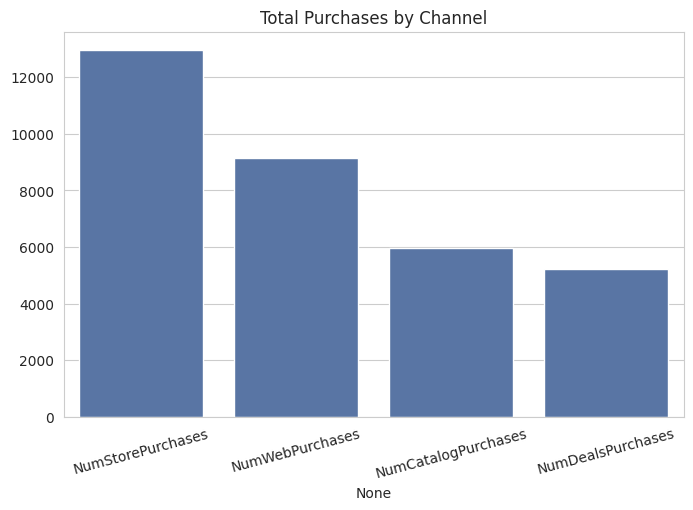

In [16]:
CHANNEL_COLS = ["NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumDealsPurchases"]
channel_totals = df[CHANNEL_COLS].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=channel_totals.index, y=channel_totals.values, color="#4C72B0")
plt.title("Total Purchases by Channel")
plt.xticks(rotation=15)
plt.show()

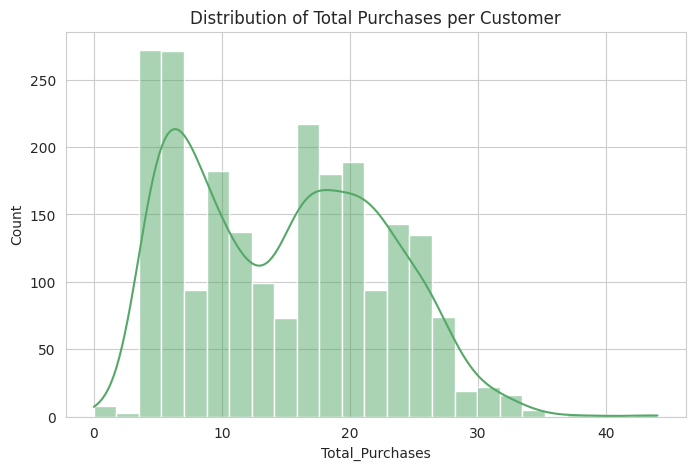

In [17]:
df["Total_Purchases"] = df[CHANNEL_COLS].sum(axis=1)
plt.figure(figsize=(8,5))
sns.histplot(df["Total_Purchases"], bins=25, kde=True, color="#55A868")
plt.title("Distribution of Total Purchases per Customer")
plt.show()

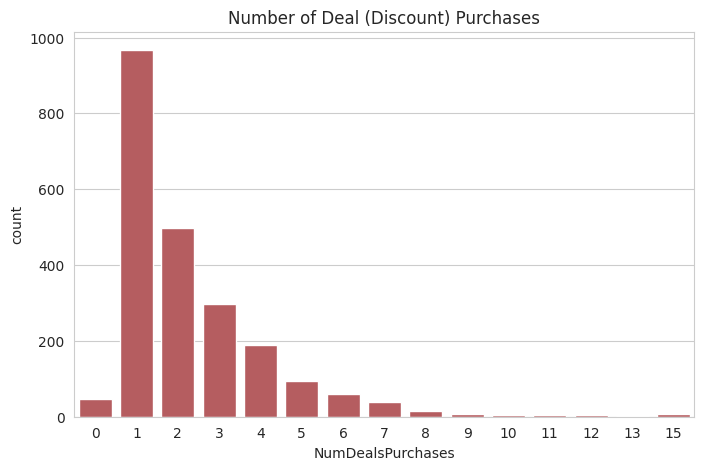

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["NumDealsPurchases"], color="#C44E52")
plt.title("Number of Deal (Discount) Purchases")
plt.show()

## Task 5 — Website Engagement Analysis

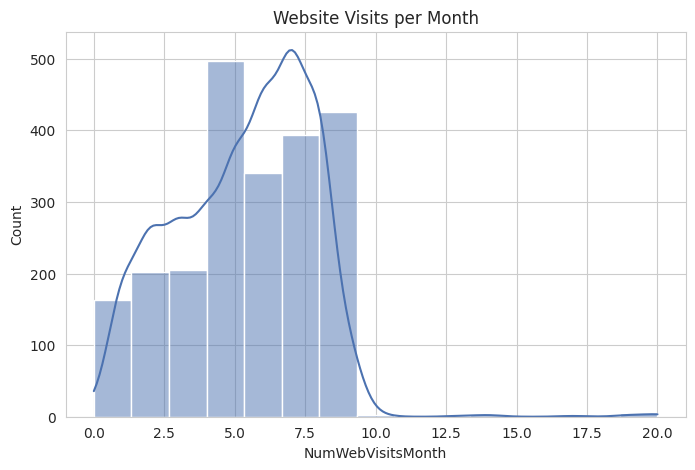

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["NumWebVisitsMonth"], bins=15, kde=True, color="#4C72B0")
plt.title("Website Visits per Month")
plt.show()

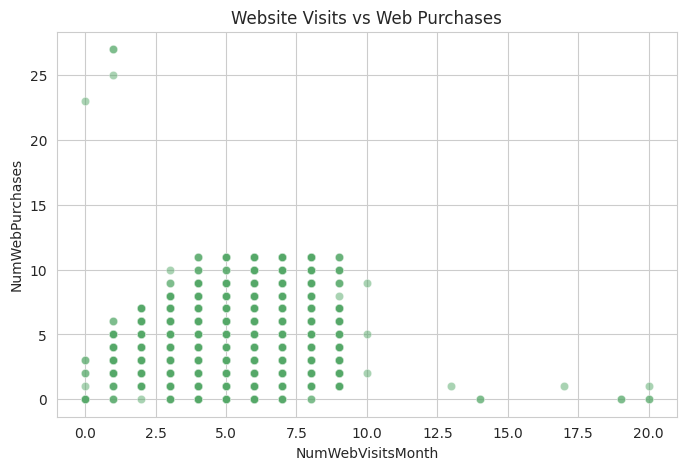

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="NumWebVisitsMonth", y="NumWebPurchases", data=df, alpha=0.5, color="#55A868")
plt.title("Website Visits vs Web Purchases")
plt.show()

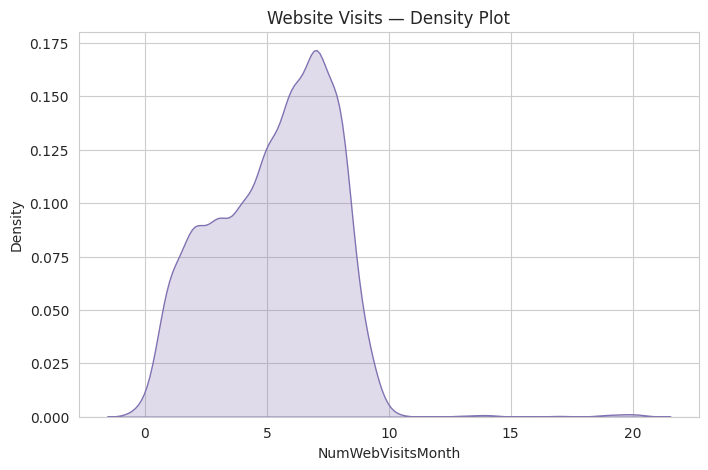

In [21]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["NumWebVisitsMonth"], fill=True, color="#8172B2")
plt.title("Website Visits — Density Plot")
plt.show()

## Task 6 — Customer Recency Analysis

**Business Insight:** customers with Recency in the top quartile (purchased
longest ago) are the priority list for re-engagement campaigns.

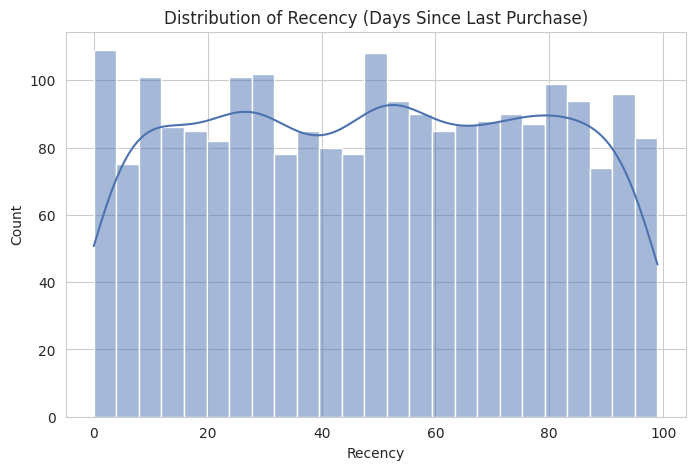

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["Recency"], bins=25, kde=True, color="#4C72B0")
plt.title("Distribution of Recency (Days Since Last Purchase)")
plt.show()

In [23]:
median_recency = df["Recency"].median()
active = df[df["Recency"] <= median_recency]
inactive = df[df["Recency"] > median_recency]
print(f"Active customers: {len(active)} | Inactive customers: {len(inactive)}")
print(f"Customers needing re-engagement (Recency > 75): {(df['Recency'] > 75).sum()}")

Active customers: 1120 | Inactive customers: 1117
Customers needing re-engagement (Recency > 75): 533


## Task 7 — Marketing Campaign Analysis

In [24]:
CAMPAIGN_COLS = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5"]
all_campaigns = CAMPAIGN_COLS + ["Response"]
labels = ["Campaign 1","Campaign 2","Campaign 3","Campaign 4","Campaign 5","Latest Campaign"]

campaign_df = pd.DataFrame({
    "Campaign": labels,
    "Accepted (Count)": [df[c].sum() for c in all_campaigns],
    "Acceptance Rate (%)": [round(df[c].mean()*100, 2) for c in all_campaigns]
})
campaign_df

,Campaign,Accepted (Count),Acceptance Rate (%)
0,Campaign 1,144,6.44
1,Campaign 2,30,1.34
2,Campaign 3,163,7.29
3,Campaign 4,167,7.47
4,Campaign 5,162,7.24
5,Latest Campaign,334,14.93


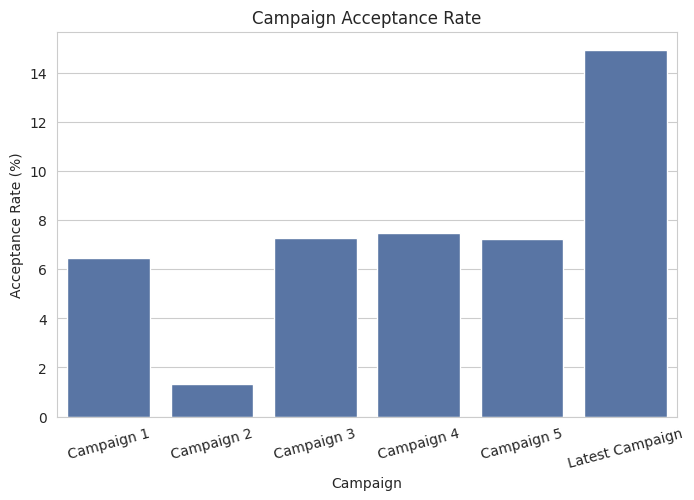

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x="Campaign", y="Acceptance Rate (%)", data=campaign_df, color="#4C72B0")
plt.title("Campaign Acceptance Rate")
plt.xticks(rotation=15)
plt.show()

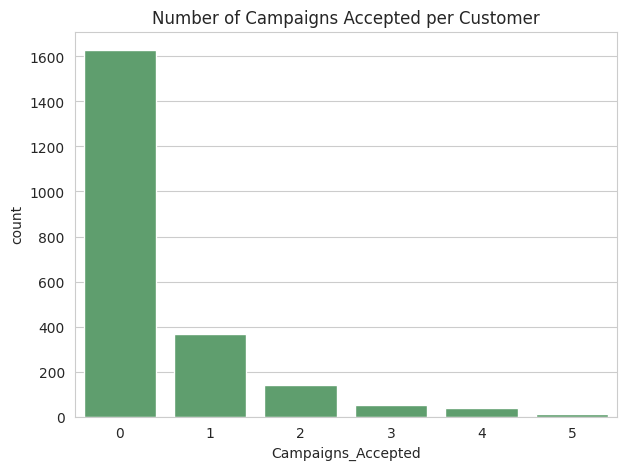

In [26]:
df["Campaigns_Accepted"] = df[all_campaigns].sum(axis=1)
plt.figure(figsize=(7,5))
sns.countplot(x=df["Campaigns_Accepted"], color="#55A868")
plt.title("Number of Campaigns Accepted per Customer")
plt.show()

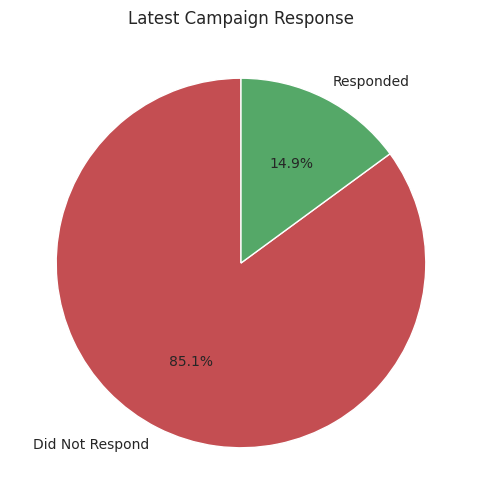

In [27]:
plt.figure(figsize=(6,6))
resp_counts = df["Response"].value_counts().rename({0:"Did Not Respond", 1:"Responded"})
plt.pie(resp_counts, labels=resp_counts.index, autopct="%1.1f%%", startangle=90, colors=["#C44E52","#55A868"])
plt.title("Latest Campaign Response")
plt.show()

## Task 8 — Customer Complaint Analysis

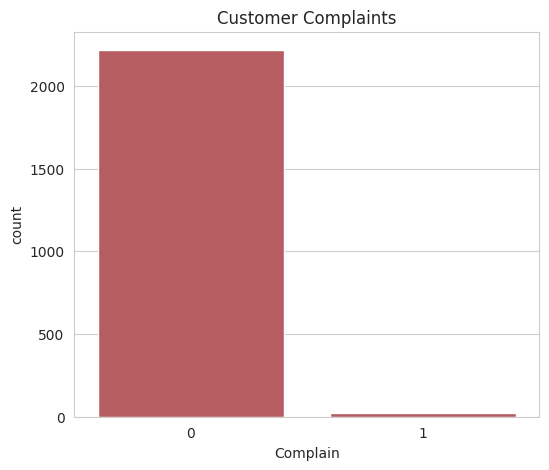

Total complaints: 20 (0.89%)


In [28]:
plt.figure(figsize=(6,5))
sns.countplot(x=df["Complain"], color="#C44E52")
plt.title("Customer Complaints")
plt.show()
print("Total complaints:", df["Complain"].sum(), f"({df['Complain'].mean()*100:.2f}%)")

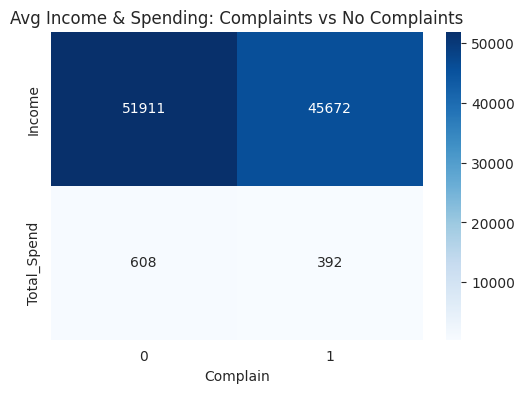

In [29]:
comp_group = df.groupby("Complain")[["Income", "Total_Spend"]].mean()
plt.figure(figsize=(6,4))
sns.heatmap(comp_group.T, annot=True, fmt=".0f", cmap="Blues")
plt.title("Avg Income & Spending: Complaints vs No Complaints")
plt.show()

## Task 9 — Correlation Analysis

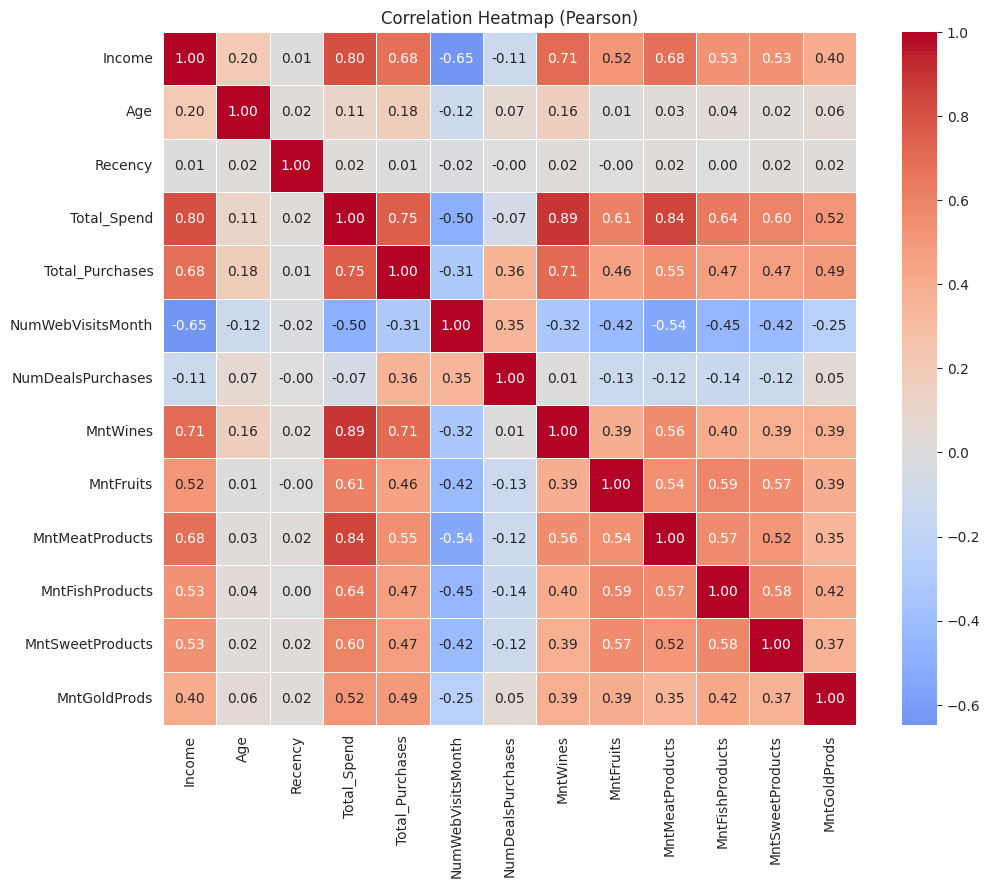

In [30]:
num_cols = ["Income","Age","Recency","Total_Spend","Total_Purchases","NumWebVisitsMonth","NumDealsPurchases"] + SPEND_COLS
corr = df[num_cols].corr(method="pearson")

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap (Pearson)")
plt.show()

In [31]:
corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]
print("Strongest positive correlations:")
print(corr_pairs.sort_values(ascending=False).head(5))
print("\nStrongest negative correlations:")
print(corr_pairs.sort_values().head(5))

Strongest positive correlations:
MntWines         Total_Spend        0.891734
Total_Spend      MntWines           0.891734
MntMeatProducts  Total_Spend        0.842655
Total_Spend      MntMeatProducts    0.842655
Income           Total_Spend        0.804182
dtype: float64

Strongest negative correlations:
Income             NumWebVisitsMonth   -0.648292
NumWebVisitsMonth  Income              -0.648292
MntMeatProducts    NumWebVisitsMonth   -0.539203
NumWebVisitsMonth  MntMeatProducts     -0.539203
Total_Spend        NumWebVisitsMonth   -0.499922
dtype: float64


## Task 10 — Customer Segmentation

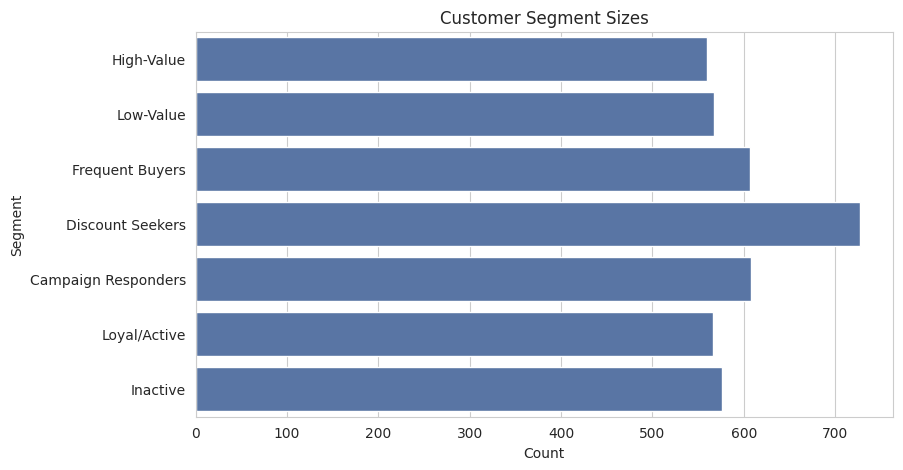

,Segment,Count
0,High-Value,560
1,Low-Value,567
2,Frequent Buyers,607
3,Discount Seekers,727
4,Campaign Responders,608
5,Loyal/Active,566
6,Inactive,576


In [32]:
high_value = df[df["Total_Spend"] >= df["Total_Spend"].quantile(0.75)]
low_value = df[df["Total_Spend"] <= df["Total_Spend"].quantile(0.25)]
frequent_buyers = df[df["Total_Purchases"] >= df["Total_Purchases"].quantile(0.75)]
discount_seekers = df[df["NumDealsPurchases"] >= df["NumDealsPurchases"].quantile(0.75)]
campaign_responders = df[df["Campaigns_Accepted"] >= 1]
loyal_customers = df[df["Recency"] <= df["Recency"].quantile(0.25)]
inactive_customers = df[df["Recency"] >= df["Recency"].quantile(0.75)]

segments = pd.DataFrame({
    "Segment": ["High-Value","Low-Value","Frequent Buyers","Discount Seekers",
                "Campaign Responders","Loyal/Active","Inactive"],
    "Count": [len(high_value), len(low_value), len(frequent_buyers), len(discount_seekers),
              len(campaign_responders), len(loyal_customers), len(inactive_customers)]
})
plt.figure(figsize=(9,5))
sns.barplot(y="Segment", x="Count", data=segments, color="#4C72B0")
plt.title("Customer Segment Sizes")
plt.show()
segments

## Task 11 — Business Insights

Answers to the key business questions, grounded in the analysis above.

In [33]:
income_spend_corr = df["Income"].corr(df["Total_Spend"])
top_category = df[SPEND_COLS].sum().idxmax()
top_channel = df[CHANNEL_COLS].sum().idxmax()
with_kids = df[(df["Kidhome"]+df["Teenhome"])>0]["Total_Spend"].mean()
without_kids = df[(df["Kidhome"]+df["Teenhome"])==0]["Total_Spend"].mean()

print(f"Income vs Total Spend correlation: {income_spend_corr:.2f}")
print(f"Highest revenue category: {top_category}")
print(f"Most popular purchase channel: {top_channel}")
print(f"Avg spend - households WITH kids/teens: {with_kids:,.0f}")
print(f"Avg spend - households WITHOUT kids/teens: {without_kids:,.0f}")

Income vs Total Spend correlation: 0.80
Highest revenue category: MntWines
Most popular purchase channel: NumStorePurchases
Avg spend - households WITH kids/teens: 407
Avg spend - households WITHOUT kids/teens: 1,105


### Summary of Key Insights

1. **Top spenders** are high-income, older customers with fewer children at home.
2. **Wine** generates the highest total revenue among product categories.
3. **Income strongly drives spending** (r ≈ 0.80).
4. **Store purchases** are the most popular channel, ahead of web and catalogue.
5. The **latest campaign** (Response) has the highest acceptance rate (~15%).
6. About **25%** of customers are inactive (high Recency) and need re-engagement.
7. **Households with children/teens spend noticeably less** than those without.
8. Spending categories are **highly correlated with each other and with Income**,
   suggesting a single "spending power" dimension drives most purchasing.
9. **Recommended strategy:** target high-income/low-recency customers with
   premium offers, launch win-back campaigns for the inactive segment, and
   promote value-oriented bundles to households with children.
